In [16]:
%pip install mediapipe numpy matplotlib opencv-python

Note: you may need to restart the kernel to use updated packages.


### Naruto Hand Gesture Recognition MediaPipe HandLandmarker + PyTorch MLP

In [17]:
DATA_DIR       = "./dataset"        
FEATURES_PATH  = "features.npz"
MODEL_PATH_OUT = "model.pt"
TEST_IMAGE     = "test.jpg"        
EPOCHS         = 300
LR             = 1e-3
BATCH_SIZE     = 32
MAX_HANDS      = 2             


In [18]:
import os, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision


%matplotlib inline

## 1. HandLandmarker setup

In [19]:
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
LANDMARKER_MODEL_PATH = "hand_landmarker.task"

def ensure_model():
    if not os.path.exists(LANDMARKER_MODEL_PATH):
        print("Downloading hand_landmarker.task ...")
        urllib.request.urlretrieve(MODEL_URL, LANDMARKER_MODEL_PATH)
    return LANDMARKER_MODEL_PATH

def make_landmarker():
    base_options = mp_python.BaseOptions(model_asset_path=ensure_model())
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.IMAGE,
        num_hands=MAX_HANDS,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
    )
    return vision.HandLandmarker.create_from_options(options)

def single_hand_vec(hand_landmarks):
    coords = np.array([[p.x, p.y, p.z] for p in hand_landmarks], dtype=np.float32)  # (21,3)
    coords -= coords[0]  # wrist-relative
    scale = np.max(np.linalg.norm(coords, axis=1))
    if scale > 1e-6:
        coords /= scale
    return coords.flatten()  

def landmarks_to_vec(result):
    """
    Builds a FIXED-SIZE, FIXED-ORDER feature vector regardless of detection order.
    MAX_HANDS=1 -> 63-d (single hand, zero vec if nothing detected — caller should skip that case).
    MAX_HANDS=2 -> 126-d = [Left hand 63-d, Right hand 63-d], zero-padded if a hand is missing.
    Ordering by handedness (not detection order) matters: without it, hand A's landmarks
    could land in slot 0 for one sample and slot 1 for another, teaching the network noise.
    """
    if MAX_HANDS == 1:
        if not result.hand_landmarks:
            return None
        return single_hand_vec(result.hand_landmarks[0])

    slots = {"Left": np.zeros(63, dtype=np.float32), "Right": np.zeros(63, dtype=np.float32)}
    for hand_landmarks, handedness in zip(result.hand_landmarks, result.handedness):
        label = handedness[0].category_name  
        slots[label] = single_hand_vec(hand_landmarks)
    return np.concatenate([slots["Left"], slots["Right"]]) 

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),        
    (0,5),(5,6),(6,7),(7,8),        
    (0,9),(9,10),(10,11),(11,12),   
    (0,13),(13,14),(14,15),(15,16), 
    (0,17),(17,18),(18,19),(19,20), 
    (5,9),(9,13),(13,17)            
]

## 2. Extract landmarks from the dataset
- Extract features from all images and store in a .npz format 
- skipping all images where hands aren't detected
- in the current dataset a good chunk is being skipped 
- Approximately ~ 1000 are dropped out of 1800 ish images

In [20]:
# drop images where hands aren't detected (because they'll only return null)
# store in a features.npz format (which is just a format for storing large arrays)

def extract_landmarks(data_dir, out_path):
    landmarker = make_landmarker()

    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(classes)}

    X, y = [], []
    per_class_counts = {c: 0 for c in classes}
    skipped = 0

    for c in classes:
        folder = os.path.join(data_dir, c)
        for fname in os.listdir(folder):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            path = os.path.join(folder, fname)
            img = cv2.imread(path)
            if img is None:
                skipped += 1
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            import mediapipe as mp
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result = landmarker.detect(mp_image)

            if not result.hand_landmarks:
                skipped += 1
                continue

            vec = landmarks_to_vec(result)
            if vec is None:
                skipped += 1
                continue

            X.append(vec)
            y.append(class_to_idx[c])
            per_class_counts[c] += 1

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    print(f"Extracted {len(X)} samples, skipped {skipped} (no hand detected / unreadable)")
    np.savez(out_path, X=X, y=y, classes=np.array(classes))
    landmarker.close()
    return X, y, classes, per_class_counts

X, y, classes, per_class_counts = extract_landmarks(DATA_DIR, FEATURES_PATH)

Extracted 1945 samples, skipped 1098 (no hand detected / unreadable)


### Class distribution
how many usable samples landed in each class after landmark detection.

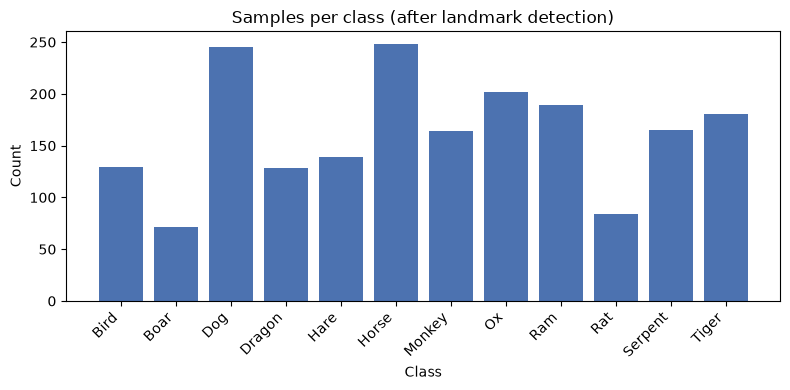

In [21]:
plt.figure(figsize=(8, 4))
plt.bar(per_class_counts.keys(), per_class_counts.values(), color="#4C72B0")
plt.title("Samples per class (after landmark detection)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Sample hand skeletons

One normalized landmark plot per class, to visually confirm the detections look sane.

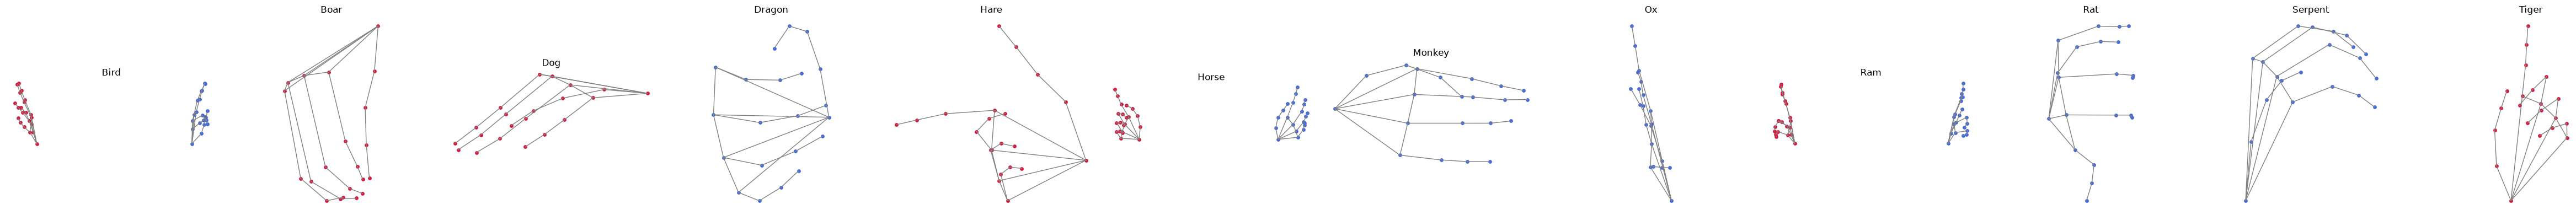

In [22]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))

if len(classes) == 1:
    axes = [axes]

def plot_hand(ax, coords, color, x_offset=0.0):
    if not np.any(coords):  # all-zero = padded/missing hand, skip drawing
        return
    for a, b in HAND_CONNECTIONS:
        ax.plot([coords[a, 0] + x_offset, coords[b, 0] + x_offset],
                [-coords[a, 1], -coords[b, 1]], "gray", linewidth=1)
    ax.scatter(coords[:, 0] + x_offset, -coords[:, 1], c=color, s=15)

for ax, c in zip(axes, classes):
    idx = np.where(y == classes.index(c))[0]
    if len(idx) == 0:
        ax.set_title(f"{c} (no samples)")
        continue
    sample = X[idx[0]]
    if MAX_HANDS == 1:
        plot_hand(ax, sample.reshape(21, 3), "crimson")
    else:
        left, right = sample[:63].reshape(21, 3), sample[63:].reshape(21, 3)
        plot_hand(ax, left, "crimson", x_offset=-1.2)
        plot_hand(ax, right, "royalblue", x_offset=1.2)
    ax.set_title(c)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Model

In [23]:
def build_model(input_dim, num_classes):
    return nn.Sequential(
        nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(64, num_classes)
    )

## 4. Train

Tracks train loss, val loss, and val accuracy per epoch for plotting afterward.

In [24]:
dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
n_val = max(1, int(0.15 * len(dataset)))
train_ds, val_ds = random_split(dataset, [len(dataset) - n_val, n_val])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("input dimensions", X.shape[1])
model = build_model(X.shape[1], len(classes)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR)
crit = nn.CrossEntropyLoss()

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_ds)

    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += crit(out, yb).item() * xb.size(0)
            pred = out.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    val_loss /= len(val_ds)
    val_acc = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"state_dict": model.state_dict(),
                    "classes": classes,
                    "input_dim": X.shape[1]}, MODEL_PATH_OUT)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f"epoch {epoch:3d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {val_acc:.4f}")

print(f"Best val_acc: {best_acc:.4f} | saved to {MODEL_PATH_OUT}")

input dimensions 126
epoch   0 | train_loss 2.1698 | val_loss 1.6558 | val_acc 0.3849
epoch  10 | train_loss 0.5327 | val_loss 0.5051 | val_acc 0.8316
epoch  20 | train_loss 0.3048 | val_loss 0.2657 | val_acc 0.9175
epoch  30 | train_loss 0.1982 | val_loss 0.1825 | val_acc 0.9313
epoch  40 | train_loss 0.1425 | val_loss 0.1550 | val_acc 0.9381
epoch  50 | train_loss 0.1235 | val_loss 0.1096 | val_acc 0.9553
epoch  60 | train_loss 0.1011 | val_loss 0.1136 | val_acc 0.9450
epoch  70 | train_loss 0.0734 | val_loss 0.1024 | val_acc 0.9588
epoch  80 | train_loss 0.0680 | val_loss 0.0763 | val_acc 0.9622
epoch  90 | train_loss 0.0651 | val_loss 0.0955 | val_acc 0.9691
epoch 100 | train_loss 0.0551 | val_loss 0.0842 | val_acc 0.9691
epoch 110 | train_loss 0.0579 | val_loss 0.0763 | val_acc 0.9691
epoch 120 | train_loss 0.0340 | val_loss 0.0799 | val_acc 0.9759
epoch 130 | train_loss 0.0368 | val_loss 0.0642 | val_acc 0.9759
epoch 140 | train_loss 0.0338 | val_loss 0.0715 | val_acc 0.9794
epoc

### Loss curves

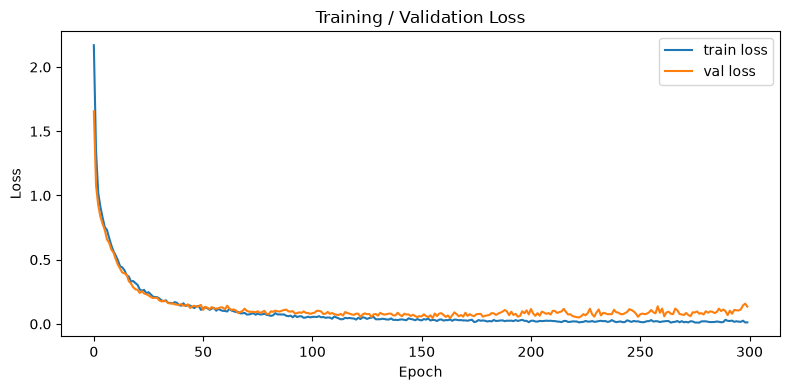

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Validation accuracy curve

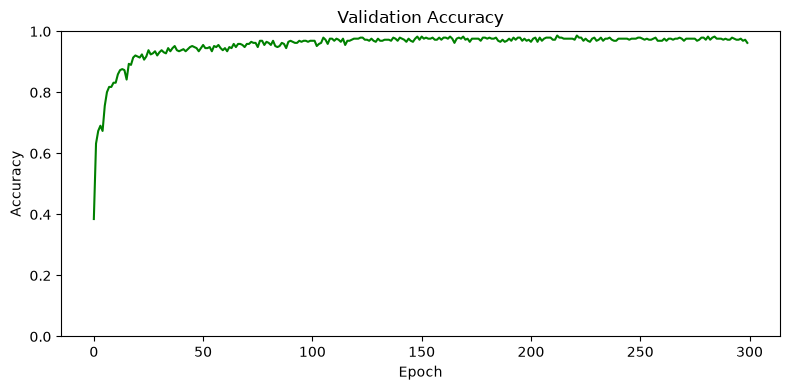

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(history["val_acc"], color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 5. Confusion matrix

Loads the best checkpoint and evaluates on the validation split.

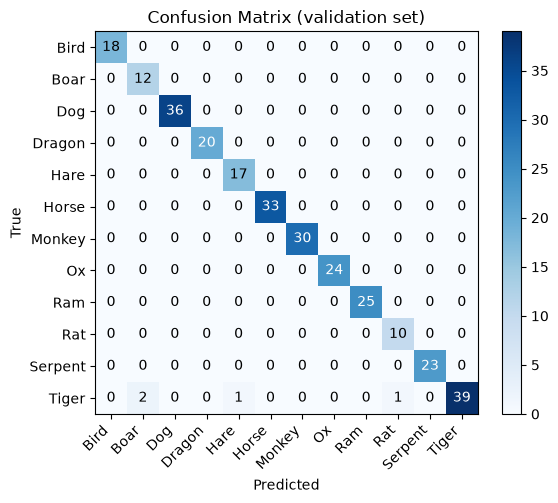

In [27]:
from sklearn.metrics import confusion_matrix

ckpt = torch.load(MODEL_PATH_OUT, map_location=device)
best_model = build_model(ckpt["input_dim"], len(classes)).to(device)
best_model.load_state_dict(ckpt["state_dict"])
best_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        pred = best_model(xb).argmax(1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (validation set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar()
plt.tight_layout()
plt.show()

### Per-class accuracy

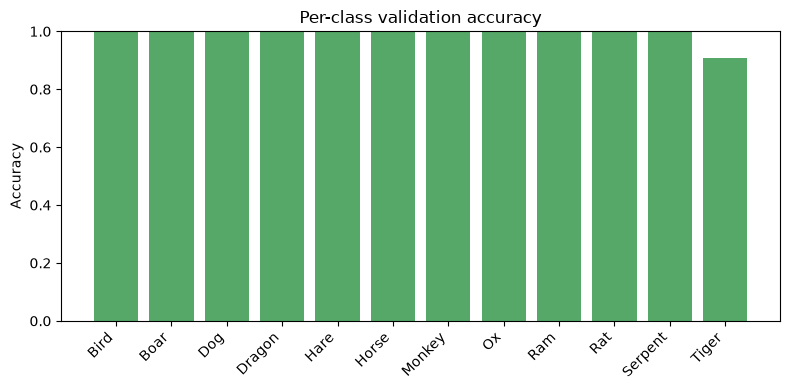

In [28]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)

plt.figure(figsize=(8, 4))
plt.bar(classes, per_class_acc, color="#55A868")
plt.title("Per-class validation accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Inference on a testing images


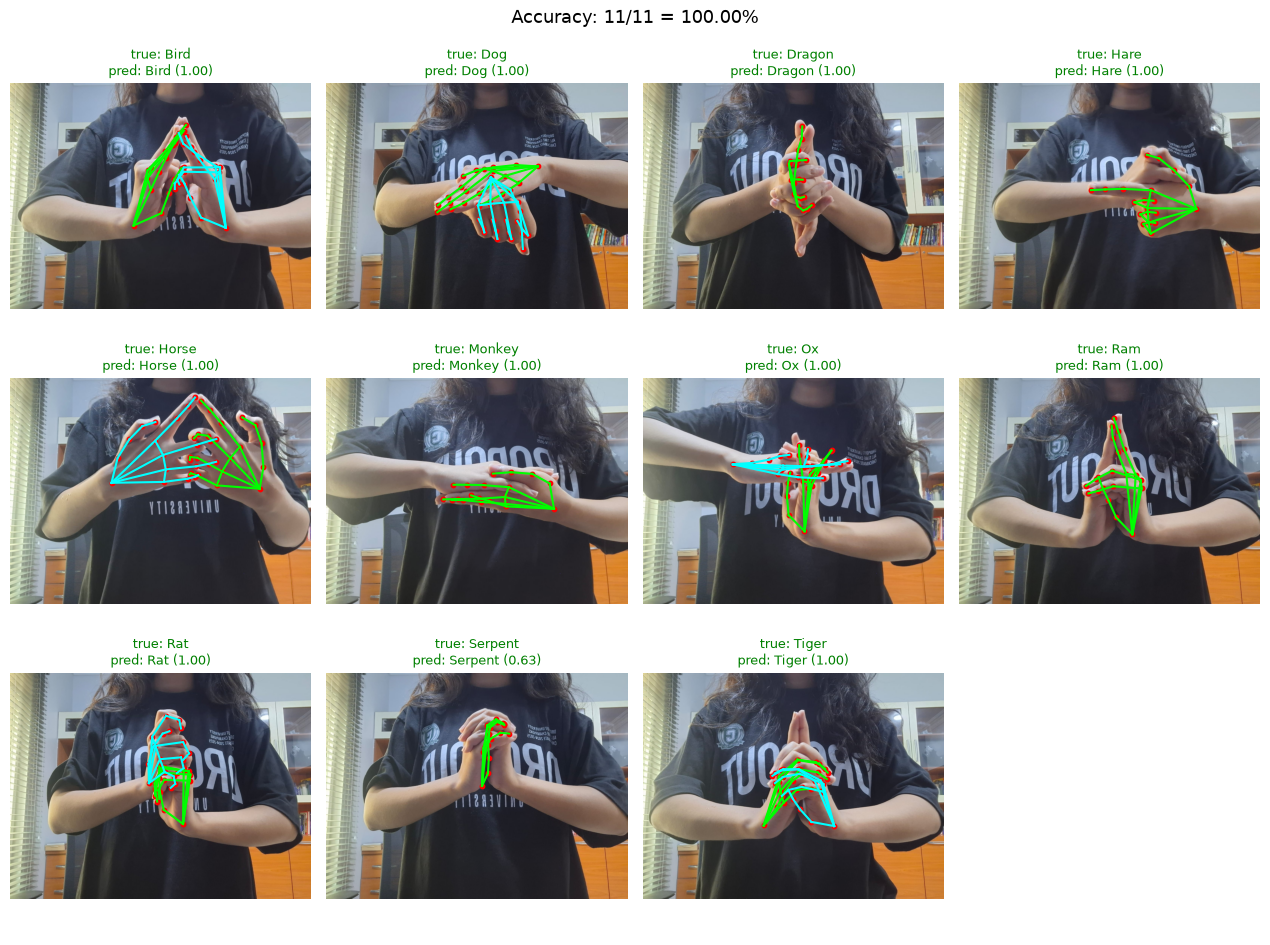

In [29]:
def infer_dataset(model_path, root_dir, cols=4, figsize_per_img=3.2, per_class=2):
    """
    Runs inference on up to `per_class` images per subdirectory under root_dir
    and displays them all in a labeled grid: true label vs predicted label.
    """
    import math
    import mediapipe as mp

    # load model + landmarker ONCE, not per image
    ckpt = torch.load(model_path, map_location="cpu")
    classes_ = ckpt["classes"]
    m = build_model(ckpt["input_dim"], len(classes_))
    m.load_state_dict(ckpt["state_dict"])
    m.eval()

    landmarker = make_landmarker()

    subdirs = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    results = []  # each: dict(img_rgb, hand_landmarks, true_label, pred_label, conf, status)

    for true_label in subdirs:
        folder = os.path.join(root_dir, true_label)
        image_files = [f for f in sorted(os.listdir(folder))
                       if f.lower().endswith((".jpg", ".jpeg", ".png"))][:per_class]

        for fname in image_files:
            path = os.path.join(folder, fname)
            img_bgr = cv2.imread(path)
            if img_bgr is None:
                continue
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result = landmarker.detect(mp_image)

            if not result.hand_landmarks:
                results.append(dict(img_rgb=img_rgb, hand_landmarks=[], true_label=true_label,
                                     pred_label=None, conf=None, status="no_hand"))
                continue

            vec = landmarks_to_vec(result)
            if vec is None:
                results.append(dict(img_rgb=img_rgb, hand_landmarks=[], true_label=true_label,
                                     pred_label=None, conf=None, status="no_hand"))
                continue

            x_t = torch.tensor(vec).unsqueeze(0)
            with torch.no_grad():
                probs = torch.softmax(m(x_t), dim=1)[0]
                idx = probs.argmax().item()
            pred_label, conf = classes_[idx], probs[idx].item()

            results.append(dict(img_rgb=img_rgb, hand_landmarks=result.hand_landmarks,
                                 true_label=true_label, pred_label=pred_label, conf=conf,
                                 status="ok"))

    landmarker.close()

    n = len(results)
    if n == 0:
        print(f"No images found under {root_dir}")
        return results

    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_img, rows * figsize_per_img))
    axes = np.array(axes).reshape(-1)

    colors = ["lime", "cyan"]
    correct, total = 0, 0

    for ax, r in zip(axes, results):
        ax.imshow(r["img_rgb"])
        h, w, _ = r["img_rgb"].shape

        if r["status"] == "no_hand":
            ax.set_title(f"true: {r['true_label']}\nNO HAND", color="orange", fontsize=9)
        else:
            for hand_landmarks, color in zip(r["hand_landmarks"], colors):
                xs = [p.x * w for p in hand_landmarks]
                ys = [p.y * h for p in hand_landmarks]
                for a, b in HAND_CONNECTIONS:
                    ax.plot([xs[a], xs[b]], [ys[a], ys[b]], color, linewidth=1.5)
                ax.scatter(xs, ys, c="red", s=10)

            is_correct = r["pred_label"] == r["true_label"]
            total += 1
            correct += int(is_correct)
            title_color = "green" if is_correct else "red"
            ax.set_title(f"true: {r['true_label']}\npred: {r['pred_label']} ({r['conf']:.2f})",
                          color=title_color, fontsize=9)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    if total > 0:
        fig.suptitle(f"Accuracy: {correct}/{total} = {correct/total:.2%}", fontsize=13)
    plt.tight_layout()
    plt.show()

    return results


results = infer_dataset('model.pt', "test-set", per_class=1)